# Cell 1 — Imports and artifact loading

In [1]:
%matplotlib inline

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import roc_auc_score

from src.utils.paths import load_paths
from src.utils.logging import setup_logger

paths = load_paths()
logger = setup_logger(level="INFO")

baseline_preds_path = paths.artifacts_dir / "balanced_bagging" / "predictions.csv"
tuned_preds_path = paths.artifacts_dir / "balanced_bagging_tuned" / "predictions.csv"

if not baseline_preds_path.exists():
    raise FileNotFoundError(f"Missing baseline predictions file: {baseline_preds_path}")

if not tuned_preds_path.exists():
    raise FileNotFoundError(f"Missing tuned predictions file: {tuned_preds_path}")

df_preds_base = pd.read_csv(baseline_preds_path)
df_preds_tuned = pd.read_csv(tuned_preds_path)

print("Baseline predictions shape:", df_preds_base.shape)
print("Tuned predictions shape:", df_preds_tuned.shape)

print("\nBaseline columns:")
print(df_preds_base.columns.tolist())

print("\nTuned columns:")
print(df_preds_tuned.columns.tolist())


Baseline predictions shape: (19908, 12)
Tuned predictions shape: (19908, 12)

Baseline columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']

Tuned columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']


# Cell 2 — Common helper functions

In [2]:
print("\n" + "=" * 80)
print("PHASE 4: ABLATION STUDY / COMPONENT CONTRIBUTION ANALYSIS")
print("=" * 80)

def tune_firewall_thresholds_quiet(df_val: pd.DataFrame, score_col: str, label_col: str = "label"):
    """
    Tune thresholds on validation:
    - BLOCK: highest recall with 0 false positive benign sessions
    - MONITOR: highest recall with <= 1 false positive benign session
    """
    y_true = df_val[label_col].astype(int).values
    scores = df_val[score_col].values

    if len(df_val) == 0:
        raise ValueError("Validation dataframe is empty.")

    desc_idx = np.argsort(scores)[::-1]
    y_sorted = y_true[desc_idx]
    s_sorted = scores[desc_idx]

    fps = np.cumsum(1 - y_sorted)

    idx_zero_fp = np.searchsorted(fps, 1, side="left") - 1
    block_thr = s_sorted[idx_zero_fp] if idx_zero_fp >= 0 else s_sorted[0] + 1e-6

    idx_one_fp = np.searchsorted(fps, 2, side="left") - 1
    monitor_thr = s_sorted[idx_one_fp] if idx_one_fp >= 0 else s_sorted[0] + 1e-6

    if monitor_thr > block_thr:
        monitor_thr = block_thr

    return float(block_thr), float(monitor_thr)


def apply_firewall_policy(df: pd.DataFrame, block_thr: float, monitor_thr: float, score_col: str):
    def classify(score):
        if score >= block_thr:
            return "BLOCK"
        if score >= monitor_thr:
            return "MONITOR"
        return "ALLOW"

    return df[score_col].apply(classify)


def calculate_firewall_metrics_quiet(df: pd.DataFrame, policy_col: str = "policy", label_col: str = "label"):
    n_total = len(df)
    n_vpn = int((df[label_col] == 1).sum())
    n_benign = int((df[label_col] == 0).sum())

    if n_total == 0:
        return {
            "block_recall": 0.0,
            "flagged_recall": 0.0,
            "block_fpr": 0.0,
            "flagged_fpr": 0.0,
            "blocked_vpn": 0,
            "blocked_benign": 0,
            "flagged_vpn": 0,
            "flagged_benign": 0,
            "auc": np.nan,
        }

    is_block = df[policy_col] == "BLOCK"
    is_flagged = df[policy_col].isin(["BLOCK", "MONITOR"])

    tp_block = int((is_block & (df[label_col] == 1)).sum())
    fp_block = int((is_block & (df[label_col] == 0)).sum())

    tp_flagged = int((is_flagged & (df[label_col] == 1)).sum())
    fp_flagged = int((is_flagged & (df[label_col] == 0)).sum())

    return {
        "block_recall": tp_block / n_vpn if n_vpn > 0 else 0.0,
        "flagged_recall": tp_flagged / n_vpn if n_vpn > 0 else 0.0,
        "block_fpr": fp_block / n_benign if n_benign > 0 else 0.0,
        "flagged_fpr": fp_flagged / n_benign if n_benign > 0 else 0.0,
        "blocked_vpn": tp_block,
        "blocked_benign": fp_block,
        "flagged_vpn": tp_flagged,
        "flagged_benign": fp_flagged,
        "auc": np.nan,
    }


def evaluate_variant(df_val: pd.DataFrame, df_test: pd.DataFrame, score_col: str, label_col: str = "label"):
    """
    Tune thresholds on validation, apply to test, compute metrics.
    Expects both df_val and df_test to already be at the correct granularity
    (flow-level or session-level).
    """
    val_local = df_val.copy()
    test_local = df_test.copy()

    block_thr, monitor_thr = tune_firewall_thresholds_quiet(val_local, score_col=score_col, label_col=label_col)

    test_local["policy"] = apply_firewall_policy(
        test_local,
        block_thr=block_thr,
        monitor_thr=monitor_thr,
        score_col=score_col
    )

    metrics = calculate_firewall_metrics_quiet(test_local, policy_col="policy", label_col=label_col)

    if test_local[label_col].nunique() > 1:
        metrics["auc"] = roc_auc_score(test_local[label_col], test_local[score_col])

    metrics["block_thr"] = block_thr
    metrics["monitor_thr"] = monitor_thr

    return metrics


def build_flow_tables(df_preds: pd.DataFrame, score_cols):
    val_flows = df_preds[df_preds["split"] == "val"].copy()
    test_flows = df_preds[df_preds["split"] == "test"].copy()

    needed_cols = ["capture_id", "dataset", "label"] + score_cols
    return val_flows[needed_cols].copy(), test_flows[needed_cols].copy()


def build_session_tables(df_preds: pd.DataFrame, score_cols):
    val_flows = df_preds[df_preds["split"] == "val"].copy()
    test_flows = df_preds[df_preds["split"] == "test"].copy()

    agg_map = {c: "mean" for c in score_cols}
    agg_map["label"] = "max"

    val_sess = (
        val_flows.groupby(["capture_id", "dataset"], as_index=False)
        .agg(agg_map)
        .copy()
    )

    test_sess = (
        test_flows.groupby(["capture_id", "dataset"], as_index=False)
        .agg(agg_map)
        .copy()
    )

    return val_sess, test_sess


def make_variant_label(row):
    return f"{row['id']}: {row['variant_name']}"



PHASE 4: ABLATION STUDY / COMPONENT CONTRIBUTION ANALYSIS


# Cell 3 — Prepare baseline and tuned tables

In [3]:
score_cols_base = ["prob_raw", "prob_iso", "prob_platt"]
score_cols_tuned = ["prob_raw", "prob_iso", "prob_platt"]

val_flows_base, test_flows_base = build_flow_tables(df_preds_base, score_cols_base)
val_sess_base, test_sess_base = build_session_tables(df_preds_base, score_cols_base)

val_flows_tuned, test_flows_tuned = build_flow_tables(df_preds_tuned, score_cols_tuned)
val_sess_tuned, test_sess_tuned = build_session_tables(df_preds_tuned, score_cols_tuned)

print("Baseline flow val/test:", val_flows_base.shape, test_flows_base.shape)
print("Baseline session val/test:", val_sess_base.shape, test_sess_base.shape)

print("Tuned flow val/test:", val_flows_tuned.shape, test_flows_tuned.shape)
print("Tuned session val/test:", val_sess_tuned.shape, test_sess_tuned.shape)


Baseline flow val/test: (1926, 6) (1844, 6)
Baseline session val/test: (45, 6) (47, 6)
Tuned flow val/test: (1926, 6) (1844, 6)
Tuned session val/test: (45, 6) (47, 6)


# Cell 4 — Run the corrected ablation

In [4]:
ablation_results = []

# A: Flow-level raw, BASELINE
print("Evaluating A: Flow-level raw (baseline)")
m = evaluate_variant(val_flows_base, test_flows_base, score_col="prob_raw")
ablation_results.append({
    "id": "A",
    "variant_name": "Flow Raw",
    "source": "baseline",
    "level": "flow",
    "prob_mode": "raw",
    "aggregation": "none",
    **m
})

# B: Flow-level isotonic, BASELINE
print("Evaluating B: Flow-level isotonic (baseline)")
m = evaluate_variant(val_flows_base, test_flows_base, score_col="prob_iso")
ablation_results.append({
    "id": "B",
    "variant_name": "Flow Isotonic",
    "source": "baseline",
    "level": "flow",
    "prob_mode": "isotonic",
    "aggregation": "none",
    **m
})

# C: Session-level raw mean, BASELINE
print("Evaluating C: Session-level raw mean (baseline)")
m = evaluate_variant(val_sess_base, test_sess_base, score_col="prob_raw")
ablation_results.append({
    "id": "C",
    "variant_name": "Session Raw Mean",
    "source": "baseline",
    "level": "session",
    "prob_mode": "raw",
    "aggregation": "mean",
    **m
})

# D: Session-level isotonic mean, BASELINE
print("Evaluating D: Session-level isotonic mean (baseline)")
m = evaluate_variant(val_sess_base, test_sess_base, score_col="prob_iso")
ablation_results.append({
    "id": "D",
    "variant_name": "Session Isotonic Mean",
    "source": "baseline",
    "level": "session",
    "prob_mode": "isotonic",
    "aggregation": "mean",
    **m
})

# E: Session-level platt mean, BASELINE
print("Evaluating E: Session-level Platt mean (baseline)")
m = evaluate_variant(val_sess_base, test_sess_base, score_col="prob_platt")
ablation_results.append({
    "id": "E",
    "variant_name": "Session Platt Mean",
    "source": "baseline",
    "level": "session",
    "prob_mode": "platt",
    "aggregation": "mean",
    **m
})

# F: Session-level isotonic mean, TUNED
print("Evaluating F: Session-level isotonic mean (tuned)")
m = evaluate_variant(val_sess_tuned, test_sess_tuned, score_col="prob_iso")
ablation_results.append({
    "id": "F",
    "variant_name": "Session Isotonic Mean Tuned",
    "source": "tuned",
    "level": "session",
    "prob_mode": "isotonic",
    "aggregation": "mean",
    **m
})

df_ablation = pd.DataFrame(ablation_results)
df_ablation["Variant"] = df_ablation.apply(make_variant_label, axis=1)

print("\nDone.")


Evaluating A: Flow-level raw (baseline)
Evaluating B: Flow-level isotonic (baseline)
Evaluating C: Session-level raw mean (baseline)
Evaluating D: Session-level isotonic mean (baseline)
Evaluating E: Session-level Platt mean (baseline)
Evaluating F: Session-level isotonic mean (tuned)

Done.


# Cell 5 — Corrected ablation summary table

In [5]:
print("\n" + "=" * 80)
print("FINAL ABLATION SUMMARY TABLE (CORRECTED)")
print("=" * 80)

display_cols = [
    "Variant",
    "source",
    "level",
    "prob_mode",
    "aggregation",
    "auc",
    "block_recall",
    "flagged_recall",
    "block_fpr",
    "flagged_fpr",
    "blocked_benign",
    "flagged_benign",
    "block_thr",
    "monitor_thr",
]

print(df_ablation[display_cols].to_string(index=False, float_format="%.4f"))



FINAL ABLATION SUMMARY TABLE (CORRECTED)
                       Variant   source   level prob_mode aggregation    auc  block_recall  flagged_recall  block_fpr  flagged_fpr  blocked_benign  flagged_benign  block_thr  monitor_thr
                   A: Flow Raw baseline    flow       raw        none 0.9457        0.4024          0.5020     0.0006       0.0006               1               1     0.9374       0.8646
              B: Flow Isotonic baseline    flow  isotonic        none 0.9474        0.5020          0.5259     0.0006       0.0006               1               1     0.9697       0.7500
           C: Session Raw Mean baseline session       raw        mean 0.9941        0.5882          0.8235     0.0000       0.0333               0               1     0.9139       0.5308
      D: Session Isotonic Mean baseline session  isotonic        mean 0.9980        0.5882          0.9412     0.0000       0.0000               0               0     0.9113       0.6622
         E: Session Pla

# Cell 6 — Component contribution deltas

In [6]:
print("\n" + "=" * 80)
print("COMPONENT CONTRIBUTION DELTAS")
print("=" * 80)

ref = df_ablation[df_ablation["id"] == "A"].iloc[0]

df_delta = df_ablation.copy()
df_delta["delta_block_recall"] = df_delta["block_recall"] - ref["block_recall"]
df_delta["delta_flagged_recall"] = df_delta["flagged_recall"] - ref["flagged_recall"]
df_delta["delta_block_fpr"] = df_delta["block_fpr"] - ref["block_fpr"]
df_delta["delta_flagged_fpr"] = df_delta["flagged_fpr"] - ref["flagged_fpr"]

delta_cols = [
    "Variant",
    "delta_block_recall",
    "delta_flagged_recall",
    "delta_block_fpr",
    "delta_flagged_fpr",
]

print(df_delta[delta_cols].to_string(index=False, float_format="%+.4f"))



COMPONENT CONTRIBUTION DELTAS
                       Variant  delta_block_recall  delta_flagged_recall  delta_block_fpr  delta_flagged_fpr
                   A: Flow Raw             +0.0000               +0.0000          +0.0000            +0.0000
              B: Flow Isotonic             +0.0996               +0.0239          +0.0000            +0.0000
           C: Session Raw Mean             +0.1858               +0.3215          -0.0006            +0.0327
      D: Session Isotonic Mean             +0.1858               +0.4392          -0.0006            -0.0006
         E: Session Platt Mean             +0.1270               +0.3215          -0.0006            -0.0006
F: Session Isotonic Mean Tuned             +0.5388               +0.4392          -0.0006            +0.0327


# Cell 7 — Specific paired comparisons that actually matter

In [7]:
print("\n" + "=" * 80)
print("PAIRED COMPARISONS")
print("=" * 80)

def print_pairwise(name_left: str, name_right: str):
    left = df_ablation[df_ablation["id"] == name_left].iloc[0]
    right = df_ablation[df_ablation["id"] == name_right].iloc[0]

    print(f"\n{name_left} -> {name_right}")
    print(f"  block_recall:   {left['block_recall']:.4f} -> {right['block_recall']:.4f}   ({right['block_recall'] - left['block_recall']:+.4f})")
    print(f"  flagged_recall: {left['flagged_recall']:.4f} -> {right['flagged_recall']:.4f}   ({right['flagged_recall'] - left['flagged_recall']:+.4f})")
    print(f"  block_fpr:      {left['block_fpr']:.4f} -> {right['block_fpr']:.4f}   ({right['block_fpr'] - left['block_fpr']:+.4f})")
    print(f"  flagged_fpr:    {left['flagged_fpr']:.4f} -> {right['flagged_fpr']:.4f}   ({right['flagged_fpr'] - left['flagged_fpr']:+.4f})")

# flow raw -> flow isotonic
print_pairwise("A", "B")

# session raw -> session isotonic
print_pairwise("C", "D")

# session isotonic baseline -> session isotonic tuned
print_pairwise("D", "F")

# session isotonic -> session platt
print_pairwise("D", "E")



PAIRED COMPARISONS

A -> B
  block_recall:   0.4024 -> 0.5020   (+0.0996)
  flagged_recall: 0.5020 -> 0.5259   (+0.0239)
  block_fpr:      0.0006 -> 0.0006   (+0.0000)
  flagged_fpr:    0.0006 -> 0.0006   (+0.0000)

C -> D
  block_recall:   0.5882 -> 0.5882   (+0.0000)
  flagged_recall: 0.8235 -> 0.9412   (+0.1176)
  block_fpr:      0.0000 -> 0.0000   (+0.0000)
  flagged_fpr:    0.0333 -> 0.0000   (-0.0333)

D -> F
  block_recall:   0.5882 -> 0.9412   (+0.3529)
  flagged_recall: 0.9412 -> 0.9412   (+0.0000)
  block_fpr:      0.0000 -> 0.0000   (+0.0000)
  flagged_fpr:    0.0000 -> 0.0333   (+0.0333)

D -> E
  block_recall:   0.5882 -> 0.5294   (-0.0588)
  flagged_recall: 0.9412 -> 0.8235   (-0.1176)
  block_fpr:      0.0000 -> 0.0000   (+0.0000)
  flagged_fpr:    0.0000 -> 0.0000   (+0.0000)


# Cell 8 — Clean plots without seaborn warning


VISUALIZATIONS


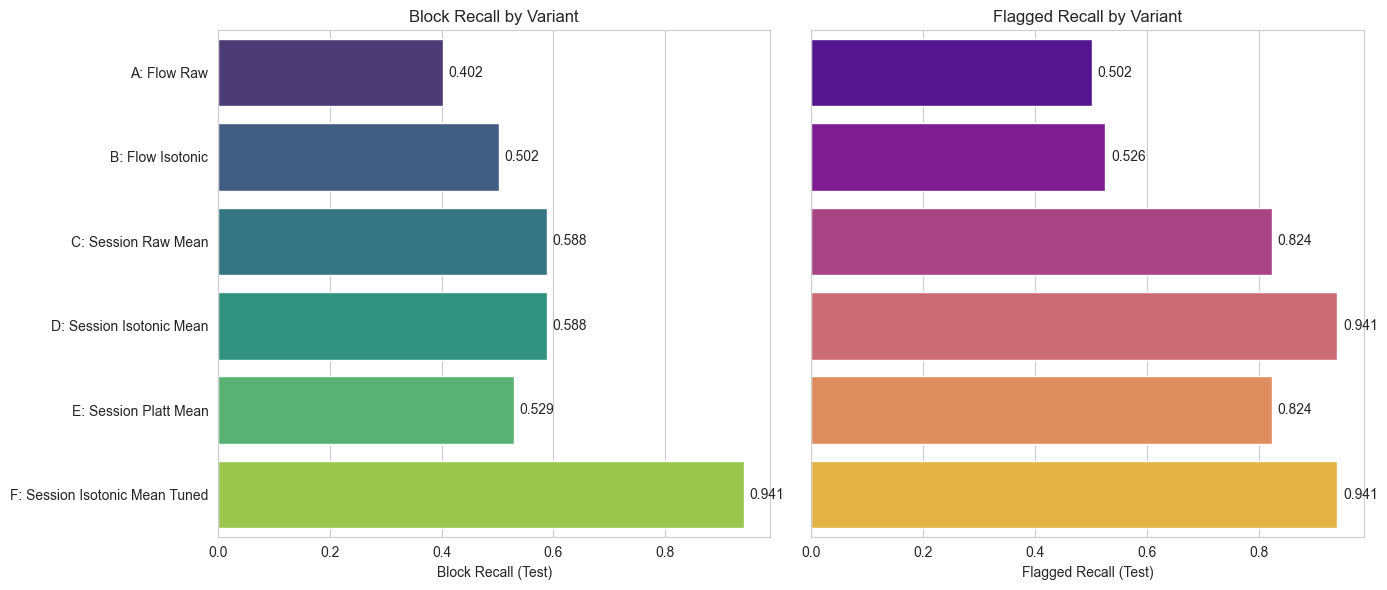

In [8]:
print("\n" + "=" * 80)
print("VISUALIZATIONS")
print("=" * 80)

sns.set_style("whitegrid")

plot_order = df_ablation["Variant"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_ablation,
    x="block_recall",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="viridis",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Block Recall by Variant")
axes[0].set_xlabel("Block Recall (Test)")
axes[0].set_ylabel("")
for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"{w:.3f}", (w + 0.01, p.get_y() + p.get_height() / 2), va="center")

sns.barplot(
    data=df_ablation,
    x="flagged_recall",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="plasma",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Flagged Recall by Variant")
axes[1].set_xlabel("Flagged Recall (Test)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", left=False, labelleft=False)
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.3f}", (w + 0.01, p.get_y() + p.get_height() / 2), va="center")

plt.tight_layout()
plt.show()


# Cell 9 — Optional firewall-focused plot

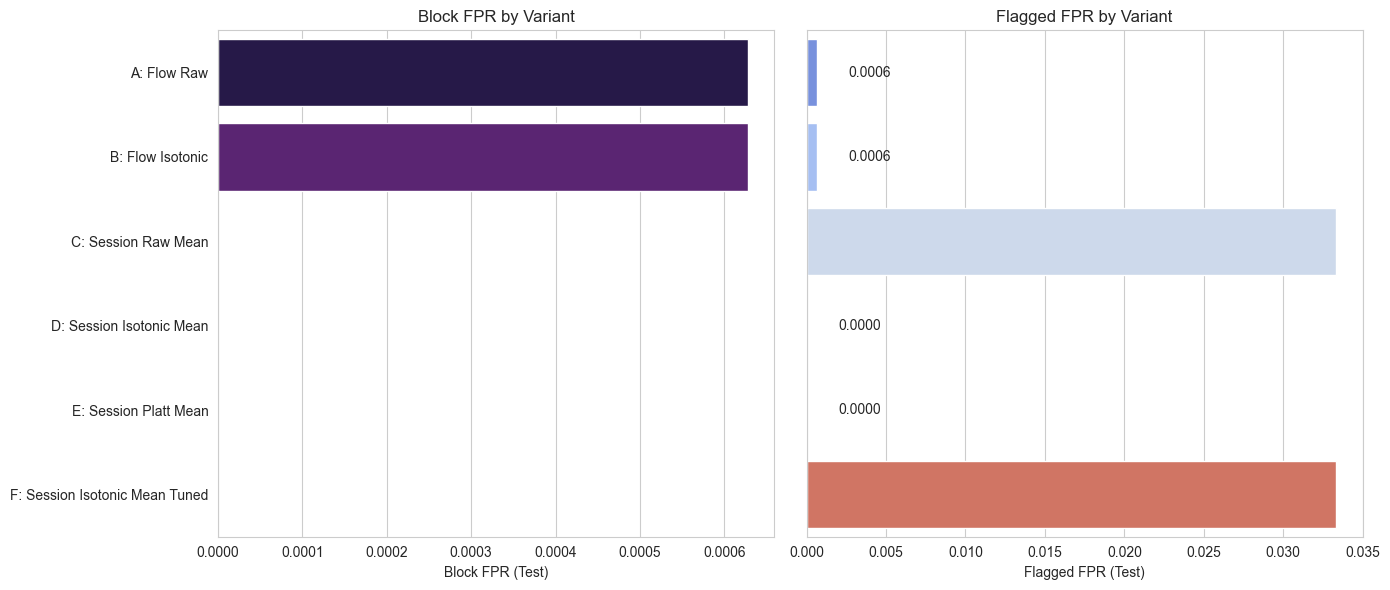

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_ablation,
    x="block_fpr",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="magma",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Block FPR by Variant")
axes[0].set_xlabel("Block FPR (Test)")
axes[0].set_ylabel("")
for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"{w:.4f}", (w + 0.002, p.get_y() + p.get_height() / 2), va="center")

sns.barplot(
    data=df_ablation,
    x="flagged_fpr",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="coolwarm",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Flagged FPR by Variant")
axes[1].set_xlabel("Flagged FPR (Test)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", left=False, labelleft=False)
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.4f}", (w + 0.002, p.get_y() + p.get_height() / 2), va="center")

plt.tight_layout()
plt.show()


# Cell 10 — Honest interpretation block

In [10]:
print("\n" + "=" * 80)
print("INTERPRETATION OF RESULTS (CORRECTED)")
print("=" * 80)
print("""
1. Session aggregation:
   This is the component expected to contribute the most. The main comparison is between
   flow-level variants (A, B) and session-level variants (C, D, E). If session-level recall
   rises strongly, that supports the firewall design claim that session aggregation matters.

2. Isotonic calibration:
   This must be judged cleanly by comparing:
   - A vs B at flow level
   - C vs D at session level
   If D is better than C under the same threshold-tuning rule, then isotonic calibration adds
   operational value. If they are nearly identical, then calibration contributes less than
   aggregation in this architecture.

3. Platt scaling:
   Compare D vs E. If E is weaker or no better than D, then isotonic remains the stronger
   calibration choice for this firewall setting.

4. Hyperparameter tuning:
   This must be judged by D vs F only:
   - D = baseline session isotonic mean
   - F = tuned session isotonic mean
   If F improves block recall or reduces false positives without hurting flagged recall,
   tuning helps. If not, then tuning adds little compared with the architectural choices.

5. Main thesis-safe conclusion:
   The clean ablation should tell you which part matters most:
   - session aggregation
   - calibration
   - tuning
   Do not claim calibration or tuning helped unless the corrected paired comparisons actually
   show it.
""")



INTERPRETATION OF RESULTS (CORRECTED)

1. Session aggregation:
   This is the component expected to contribute the most. The main comparison is between
   flow-level variants (A, B) and session-level variants (C, D, E). If session-level recall
   rises strongly, that supports the firewall design claim that session aggregation matters.

2. Isotonic calibration:
   This must be judged cleanly by comparing:
   - A vs B at flow level
   - C vs D at session level
   If D is better than C under the same threshold-tuning rule, then isotonic calibration adds
   operational value. If they are nearly identical, then calibration contributes less than
   aggregation in this architecture.

3. Platt scaling:
   Compare D vs E. If E is weaker or no better than D, then isotonic remains the stronger
   calibration choice for this firewall setting.

4. Hyperparameter tuning:
   This must be judged by D vs F only:
   - D = baseline session isotonic mean
   - F = tuned session isotonic mean
   If F impro